# Домашнє завдання 16. PCA і якість класифікації
Дата заняття: 07.07.2026 (вт)
Модуль: Модуль 7. Навчання без учителя

#### Мета
Застосувати PCA для зниження розмірності даних і перевірити, як кількість головних компонентів впливає на якість моделі класифікації.

### Завдання
Створити notebook homework_16_pca_classification.ipynb.

## PCA і класифікація

#### Завдання
1. Завантажте датасет sklearn.datasets.load_wine.
2. Перетворіть дані на pandas.DataFrame.
3. Масштабуйте ознаки за допомогою StandardScaler.
4. Розділіть дані на навчальну і тестову вибірки у співвідношенні 80/20.

## PCA-візуалізація

#### Завдання
1.  Імпортуйте PCA з sklearn.decomposition.
2. Створіть PCA-модель з параметром n_components=2.
3. Виконайте перетворення даних.
4. Побудуйте scatter-графік за двома головними компонентами.
5. Розфарбуйте точки за цільовим класом target.
6. Додайте підписи осей і заголовок PCA Components Visualization.

## Вплив кількості компонентів на модель

#### Завдання
1.  Використайте модель LogisticRegression з sklearn.linear_model.
2. Навчіть модель тричі: з 2, 5 і 10 компонентами PCA.
3. Для кожного варіанта обчисліть accuracy_score на тестовій вибірці.
4. Виведіть результати в notebook.
5. Побудуйте графік залежності точності від кількості компонентів:
    * по осі X - кількість компонентів;
    * по осі Y - точність класифікації accuracy.
6. Додайте підписи осей і заголовок PCA Accuracy vs Components.
7. Збережіть графік у файл pca_accuracy_results.png.
8. Напишіть короткий висновок: як кількість компонентів вплинула на якість класифікації і який варіант виглядає найкращим.

##### Що здати
Файл homework_16_pca_classification.ipynb.
Зображення pca_accuracy_results.png.

In [3]:
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd
from sklearn.datasets import load_wine
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler

plt.style.use("seaborn-v0_8-whitegrid")
OUTPUT_DIR = Path.cwd()

In [4]:
wine = load_wine()

X = pd.DataFrame(wine.data, columns=wine.feature_names)
y = pd.Series(wine.target, name="target")

display(X.head())
print(f"Розмір матриці ознак: {X.shape[0]} рядків x {X.shape[1]} ознак")
print(f"Класи: {list(wine.target_names)}")

,alcohol,malic_acid,ash,alcalinity_of_ash,magnesium,total_phenols,flavanoids,nonflavanoid_phenols,proanthocyanins,color_intensity,hue,od280/od315_of_diluted_wines,proline
0,14.23,1.71,2.43,15.6,127.0,2.80,3.06,0.28,2.29,5.64,1.04,3.92,1065.0
1,13.20,1.78,2.14,11.2,100.0,2.65,2.76,0.26,1.28,4.38,1.05,3.40,1050.0
2,13.16,2.36,2.67,18.6,101.0,2.80,3.24,0.30,2.81,5.68,1.03,3.17,1185.0
3,14.37,1.95,2.50,16.8,113.0,3.85,3.49,0.24,2.18,7.80,0.86,3.45,1480.0
4,13.24,2.59,2.87,21.0,118.0,2.80,2.69,0.39,1.82,4.32,1.04,2.93,735.0


Розмір матриці ознак: 178 рядків x 13 ознак
Класи: [np.str_('class_0'), np.str_('class_1'), np.str_('class_2')]


In [5]:
scale_summary = pd.DataFrame({
    "mean_before": X.mean(),
    "std_before": X.std()
}).round(2)

scale_summary.head(8)

,mean_before,std_before
alcohol,13.00,0.81
malic_acid,2.34,1.12
ash,2.37,0.27
alcalinity_of_ash,19.49,3.34
magnesium,99.74,14.28
total_phenols,2.30,0.63
flavanoids,2.03,1.00
nonflavanoid_phenols,0.36,0.12


In [6]:
scaler = StandardScaler()

X_scaled = scaler.fit_transform(X)

scaled_summary = pd.DataFrame(X_scaled, columns=X.columns).agg(["mean", "std"]).T
scaled_summary.head(8).round(2)

,mean,std
alcohol,-0.0,1.0
malic_acid,-0.0,1.0
ash,-0.0,1.0
alcalinity_of_ash,-0.0,1.0
magnesium,-0.0,1.0
total_phenols,0.0,1.0
flavanoids,-0.0,1.0
nonflavanoid_phenols,0.0,1.0


In [7]:
from sklearn.model_selection import train_test_split


X_train, X_test, y_train, y_test = train_test_split(
    X_scaled,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

In [8]:
from sklearn.decomposition import PCA

In [9]:
pca_2d = PCA(n_components=2)

X_pca = pca_2d.fit_transform(X_scaled)

In [10]:
X_pca_df = pd.DataFrame(X_pca, columns=["PC 1", "PC 2"])
X_pca_df 

,PC 1,PC 2
0,3.316751,1.443463
1,2.209465,-0.333393
2,2.516740,1.031151
3,3.757066,2.756372
4,1.008908,0.869831
...,...,...
173,-3.370524,2.216289
174,-2.601956,1.757229
175,-2.677839,2.760899
176,-2.387017,2.297347


In [13]:
X_pca_df["target"] = y
X_pca_df['class_name'] = y.map({i: name for i, name in enumerate(wine.target_names)})
X_pca_df

,PC 1,PC 2,target,class_name
0,3.316751,1.443463,0,class_0
1,2.209465,-0.333393,0,class_0
2,2.516740,1.031151,0,class_0
3,3.757066,2.756372,0,class_0
4,1.008908,0.869831,0,class_0
...,...,...,...,...
173,-3.370524,2.216289,2,class_2
174,-2.601956,1.757229,2,class_2
175,-2.677839,2.760899,2,class_2
176,-2.387017,2.297347,2,class_2


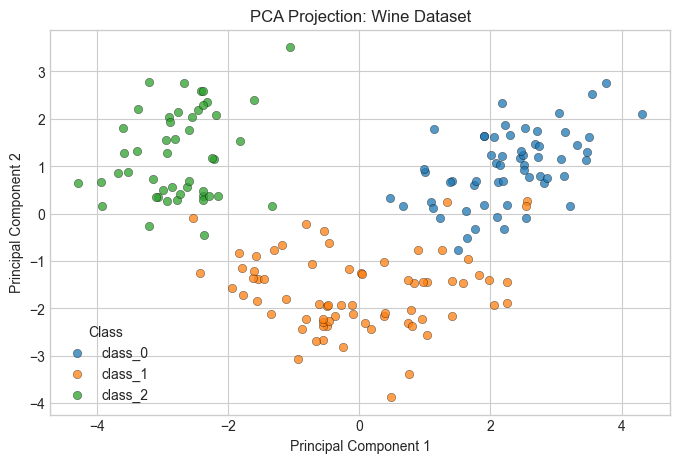

In [15]:
fig, ax = plt.subplots(figsize=(8, 5))

for target_value, class_name in enumerate(wine.target_names):
    subset = X_pca_df[X_pca_df["target"] == target_value]

    ax.scatter(
        subset["PC 1"],
        subset["PC 2"],
        label = class_name,
        alpha = 0.75,
        edgecolors = "black",
        linewidth=0.3

    )

ax.set_title("PCA Projection: Wine Dataset")

ax.set_xlabel("Principal Component 1")
ax.set_ylabel("Principal Component 2")

ax.legend(title="Class")

plt.show()


In [20]:
from sklearn.linear_model import LogisticRegression

model = LogisticRegression(random_state=42, max_iter=1000)

n_components_list = [2, 5, 10]
results = []

for n in n_components_list:
    pca = PCA(n_components=n)
    X_train_pca = pca.fit_transform(X_train)
    X_test_pca = pca.transform(X_test)

    model = LogisticRegression(random_state=42, max_iter=1000)
    model.fit(X_train_pca, y_train)

    train_scores = model.score(X_train_pca, y_train)
    test_scores = model.score(X_test_pca, y_test)

    results.append({
        "n_components": n,
        "train_scores": train_scores,
        "test_scores": test_scores,
        "explained_variance": pca.explained_variance_ratio_.sum()
    })

    print(f"Компонент: {n}")
    print(f"Train accurancy:  {train_scores}")
    print(f"Test accurancy:  {test_scores}")
    print(f"Explained variance: {pca.explained_variance_ratio_.sum()}")

Компонент: 2
Train accurancy:  0.971830985915493
Test accurancy:  0.9166666666666666
Explained variance: 0.5462601439223009
Компонент: 5
Train accurancy:  0.9929577464788732
Test accurancy:  0.9722222222222222
Explained variance: 0.8014090057373177
Компонент: 10
Train accurancy:  1.0
Test accurancy:  0.9722222222222222
Explained variance: 0.962916300764833


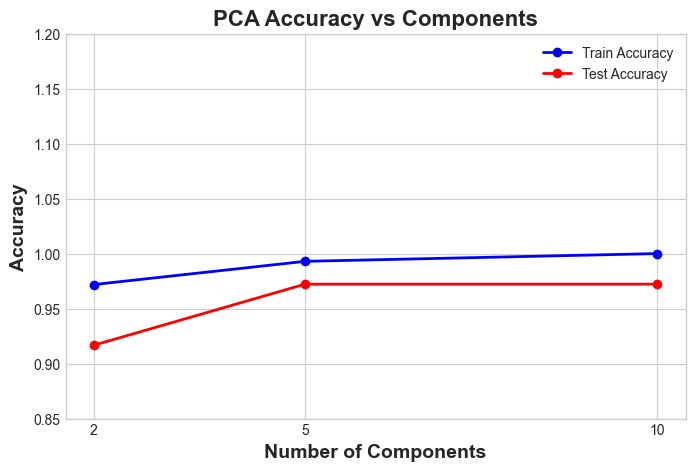

In [28]:
n_components_list = [r["n_components"] for r in results]
train_scores = [r["train_scores"] for r in results]
test_scores = [r["test_scores"] for r in results]
explained_variance = [r["explained_variance"] for r in results]

fig, ax = plt.subplots(figsize=(8, 5))

ax.plot(
    n_components_list,
    train_scores,
    marker="o",
    color="blue",
    label="Train Accuracy",
    linewidth=2
)


ax.plot(
    n_components_list,
    test_scores,
    marker="o",
    color="red",
    label="Test Accuracy",
    linewidth=2
)
ax.set_title("PCA Accuracy vs Components", fontsize=16, fontweight="bold")
ax.set_xlabel("Number of Components", fontsize=14, fontweight="bold")
ax.set_ylabel("Accuracy", fontsize=14, fontweight="bold")

ax.set_xticks(n_components_list)
ax.set_ylim(0.85, 1.2)

ax.legend()
ax.grid(True)

plt.savefig("pca_accuracy_results.png", dpi=300, bbox_inches="tight")

plt.show()

З трьох навчених моделей, більш точною та ефективною виявилася та що розрахована на 5 компонентів. Вона виявилась найбіль точною,  де показники як навчання високі (99% ), так і н тестових даних 97% - різниця, на мою думку, невелика.  

В першому варіанті, там де 2 - на тренуванні результат гарний, але на тестовому варіанті різниця більше 5 одиниць. 

В останньому варіанті, модель проявляє гарний результат, найвищий показник під час навчання, але від цього тестовий результат не змінився. 
